# Benchmark the convergence-matched U-Tikhonov 2×2 ablation

This notebook evaluates only the four validation-selected U-Tikhonov
checkpoints. It recreates the exact deterministic DIV2K and geometric
samples used by the principal benchmark, checks their identities against
the earlier manifest when available, and computes:

- absolute PSNR/SSIM/MSE summaries;
- paired 95% bootstrap confidence intervals;
- one-factor effects of λ-bound and CG depth;
- the 2×2 interaction (difference in differences);
- per-image best counts, parameter-map diagnostics, and inference time.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Put this notebook in "
        "cleaned_pipeline/notebooks or start Jupyter from the project."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
import re
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import ConcatDataset, DataLoader, Subset

from src.data.benchmark_dataset import (
    GeometricShapesDataset,
    MultiNoiseBenchmarkDataset,
    benchmark_manifest,
)
from src.data.div2k_dataset import DIV2KDenoisingDataset
from src.evaluation.benchmark import (
    benchmark_inference_runtime,
    best_method_counts,
    load_checkpoint,
    load_project_model,
    method_summary,
    paired_difference_summary,
    runtime_summary,
    validate_paired_results,
)
from src.evaluation.denoising_eval import evaluate_denoising_model
from src.training.denoising import get_device

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Paths, checkpoints, and strict model checks


In [3]:
FIRST_TRY_ROOT = PROJECT_ROOT.parent / "First Try"


def locate_div2k_validation_root():
    likely_paths = [
        FIRST_TRY_ROOT / "DIV2K" / "DIV2K_valid_HR",
        FIRST_TRY_ROOT / "Datasets" / "DIV2K" / "DIV2K_valid_HR",
        FIRST_TRY_ROOT / "data" / "DIV2K" / "DIV2K_valid_HR",
        Path.home() / "Datasets" / "DIV2K" / "DIV2K_valid_HR",
    ]
    for path in likely_paths:
        if path.is_dir():
            return path.resolve()
    if FIRST_TRY_ROOT.is_dir():
        matches = sorted(
            path.resolve()
            for path in FIRST_TRY_ROOT.rglob("DIV2K_valid_HR")
            if path.is_dir()
        )
        if len(matches) == 1:
            return matches[0]
    raise FileNotFoundError("DIV2K_valid_HR was not found. Set DIV2K_ROOT.")


DIV2K_ROOT = locate_div2k_validation_root()
IMAGE_SIZE = 256
SIGMAS = (0.05, 0.10, 0.15, 0.20)
TEST_NOISE_SEED = 20_000
OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "u_tikhonov_convergence_matched_2x2"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_paths = OrderedDict(
    [
        (
            "U-Tikhonov T4/CG32",
            PROJECT_ROOT / "checkpoints"
            / "u_tikhonov_bounded_x4_cg32_e300_resumed_from_e200"
            / "u_tikhonov_best.pth",
        ),
        (
            "U-Tikhonov T4/CG64",
            PROJECT_ROOT / "checkpoints"
            / "u_tikhonov_bounded_x4_cg64_e300_resumed_from_e200"
            / "u_tikhonov_best.pth",
        ),
        (
            "U-Tikhonov T16/CG32",
            PROJECT_ROOT / "checkpoints"
            / "u_tikhonov_bounded_x16_cg32_e300_resumed_from_e200"
            / "u_tikhonov_best.pth",
        ),
        (
            "U-Tikhonov T16/CG64",
            PROJECT_ROOT / "checkpoints"
            / "u_tikhonov_bounded_x16_cg64_e300_resumed_from_e200"
            / "u_tikhonov_best.pth",
        ),
    ]
)

expected_factors = {
    "U-Tikhonov T4/CG32": (4.0, 32),
    "U-Tikhonov T4/CG64": (4.0, 64),
    "U-Tikhonov T16/CG32": (16.0, 32),
    "U-Tikhonov T16/CG64": (16.0, 64),
}

models = OrderedDict()
checkpoints = {}
configuration_rows = []
for method, path in checkpoint_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing final checkpoint: {path}")
    run_history = pd.read_csv(path.parent / "history.csv")
    if int(run_history["epoch"].max()) != 300:
        raise RuntimeError(f"{method}: training history does not reach epoch 300.")

    model, checkpoint = load_project_model(path, device)
    args = dict(checkpoint["args"])
    expected_multiplier, expected_cg = expected_factors[method]
    reference_lambda = float(args["reference_lambda"])
    actual_multiplier = float(args["lambda_max"]) / reference_lambda
    if not np.isclose(actual_multiplier, expected_multiplier, atol=1e-6):
        raise RuntimeError(f"{method}: incorrect lambda upper bound.")
    if int(args["cg_iters"]) != expected_cg:
        raise RuntimeError(f"{method}: incorrect CG depth.")

    models[method] = model
    checkpoints[method] = checkpoint
    configuration_rows.append(
        {
            "method": method,
            "selected_epoch": int(checkpoint["epoch"]),
            "trained_epochs": 300,
            "parameter_count": sum(p.numel() for p in model.parameters()),
            "lambda_multiplier": actual_multiplier,
            "lambda_min": float(args["lambda_min"]),
            "lambda_max": float(args["lambda_max"]),
            "cg_iterations": int(args["cg_iters"]),
            "checkpoint": str(path),
        }
    )

model_configuration = pd.DataFrame(configuration_rows)
model_configuration.to_csv(OUTPUT_DIR / "model_configuration.csv", index=False)
display(model_configuration)


,method,selected_epoch,trained_epochs,parameter_count,lambda_multiplier,lambda_min,lambda_max,cg_iterations,checkpoint
0,U-Tikhonov T4/CG32,259,300,1925025,4.0,0.0001,8.320335,32,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-Tikhonov T4/CG64,293,300,1925025,4.0,0.0001,8.320335,64,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T16/CG32,249,300,1925025,16.0,0.0001,33.281341,32,/Users/kyrillguba/Documents/Data Analytics MSc...
3,U-Tikhonov T16/CG64,269,300,1925025,16.0,0.0001,33.281341,64,/Users/kyrillguba/Documents/Data Analytics MSc...


## Recreate and verify the exact paired benchmark


In [4]:
div2k_clean = DIV2KDenoisingDataset(
    root_dir=DIV2K_ROOT,
    image_size=IMAGE_SIZE,
    sigma_min=0.0,
    sigma_max=0.0,
    max_images=None,
    seed=42,
)
if len(div2k_clean) != 100:
    raise RuntimeError(f"Expected 100 DIV2K validation images, found {len(div2k_clean)}.")

geometric_clean = GeometricShapesDataset(image_size=IMAGE_SIZE)
div2k_benchmark = MultiNoiseBenchmarkDataset(
    div2k_clean,
    sigmas=SIGMAS,
    seed=TEST_NOISE_SEED,
    dataset_name="div2k",
    paired_noise_across_sigmas=True,
)
geometric_benchmark = MultiNoiseBenchmarkDataset(
    geometric_clean,
    sigmas=SIGMAS,
    seed=TEST_NOISE_SEED + 100_000,
    dataset_name="geometry",
    paired_noise_across_sigmas=True,
)
benchmark_dataset = ConcatDataset([div2k_benchmark, geometric_benchmark])
benchmark_loader = DataLoader(
    benchmark_dataset, batch_size=1, shuffle=False, num_workers=0
)

manifest = pd.concat(
    [benchmark_manifest(div2k_benchmark), benchmark_manifest(geometric_benchmark)],
    ignore_index=True,
)
if len(manifest) != 420 or manifest["sample_id"].duplicated().any():
    raise RuntimeError("The benchmark manifest is not the expected 420 unique samples.")

identity_columns = [
    "sample_id",
    "dataset",
    "image_name",
    "sigma",
    "noise_seed",
    "clean_sha256",
    "noisy_sha256",
]


def compare_manifests(current, reference, reference_path):
    """Compare manifests by sample ID rather than CSV row order."""
    missing = [
        column
        for column in identity_columns
        if column not in reference.columns
    ]
    if missing:
        return {
            "reference": str(reference_path),
            "exact_match": False,
            "new_only_ids": np.nan,
            "old_only_ids": np.nan,
            "dataset_mismatches": np.nan,
            "image_name_mismatches": np.nan,
            "sigma_mismatches": np.nan,
            "noise_seed_mismatches": np.nan,
            "clean_hash_mismatches": np.nan,
            "noisy_hash_mismatches": np.nan,
            "problem": f"missing columns: {missing}",
        }

    current = current[identity_columns].copy()
    reference = reference[identity_columns].copy()

    if current["sample_id"].duplicated().any():
        raise RuntimeError(
            "The newly generated manifest contains duplicate sample IDs."
        )
    if reference["sample_id"].duplicated().any():
        raise RuntimeError(
            f"The reference contains duplicate sample IDs: "
            f"{reference_path}"
        )

    current_ids = set(current["sample_id"].astype(str))
    reference_ids = set(reference["sample_id"].astype(str))

    new_only = current_ids - reference_ids
    old_only = reference_ids - current_ids

    merged = current.merge(
        reference,
        on="sample_id",
        suffixes=("_new", "_old"),
        validate="one_to_one",
    )

    text_columns = [
        "dataset",
        "image_name",
        "clean_sha256",
        "noisy_sha256",
    ]

    mismatch_counts = {}
    for column in text_columns:
        mismatch_counts[column] = int(
            (
                merged[f"{column}_new"].astype(str)
                != merged[f"{column}_old"].astype(str)
            ).sum()
        )

    sigma_mismatches = int(
        (
            ~np.isclose(
                pd.to_numeric(
                    merged["sigma_new"]
                ).to_numpy(dtype=float),
                pd.to_numeric(
                    merged["sigma_old"]
                ).to_numpy(dtype=float),
                rtol=0.0,
                atol=1e-7,
            )
        ).sum()
    )

    noise_seed_mismatches = int(
        (
            pd.to_numeric(
                merged["noise_seed_new"]
            ).to_numpy(dtype=np.int64)
            != pd.to_numeric(
                merged["noise_seed_old"]
            ).to_numpy(dtype=np.int64)
        ).sum()
    )

    exact_match = (
        len(current) == len(reference)
        and not new_only
        and not old_only
        and sigma_mismatches == 0
        and noise_seed_mismatches == 0
        and all(count == 0 for count in mismatch_counts.values())
    )

    return {
        "reference": str(reference_path),
        "exact_match": exact_match,
        "new_only_ids": len(new_only),
        "old_only_ids": len(old_only),
        "dataset_mismatches": mismatch_counts["dataset"],
        "image_name_mismatches": mismatch_counts["image_name"],
        "sigma_mismatches": sigma_mismatches,
        "noise_seed_mismatches": noise_seed_mismatches,
        "clean_hash_mismatches": mismatch_counts["clean_sha256"],
        "noisy_hash_mismatches": mismatch_counts["noisy_sha256"],
        "problem": "",
    }


# Find all earlier benchmark manifests. Exclude the output currently
# being generated by this notebook.
current_manifest_path = (
    OUTPUT_DIR / "benchmark_manifest.csv"
).resolve()

preferred_candidates = [
    PROJECT_ROOT
    / "results"
    / "benchmark_v1_with_official_deal"
    / "benchmark_manifest.csv",

    PROJECT_ROOT
    / "results"
    / "benchmark_v1"
    / "benchmark_manifest.csv",
]

discovered_candidates = sorted(
    (PROJECT_ROOT / "results").rglob(
        "benchmark_manifest.csv"
    )
)

reference_candidates = []
for path in [
    *preferred_candidates,
    *discovered_candidates,
]:
    path = path.resolve()

    if (
        path.is_file()
        and path != current_manifest_path
        and path not in reference_candidates
    ):
        reference_candidates.append(path)


comparison_rows = []
exact_matches = []

for reference_path in reference_candidates:
    old_manifest = pd.read_csv(reference_path)

    report = compare_manifests(
        manifest,
        old_manifest,
        reference_path,
    )
    comparison_rows.append(report)

    if report["exact_match"]:
        exact_matches.append(reference_path)

comparison_report = pd.DataFrame(comparison_rows)
display(comparison_report)
comparison_report.to_csv(
    OUTPUT_DIR / "manifest_verification_report.csv",
    index=False,
)

if reference_candidates and not exact_matches:
    raise RuntimeError(
        "None of the previous benchmark manifests matches the "
        "newly recreated samples. Do not run model evaluation yet; "
        "inspect the mismatch report above."
    )

if exact_matches:
    reference_manifest = exact_matches[0]
    print(
        "Exact sample IDs, seeds and tensor hashes match:",
        reference_manifest,
    )
else:
    reference_manifest = None
    print(
        "No earlier manifest was found. The deterministic manifest "
        "has been generated, but cross-run identity could not be checked."
    )
manifest.to_csv(OUTPUT_DIR / "benchmark_manifest.csv", index=False)
display(manifest.groupby(["dataset", "sigma"]).size().rename("images"))


,reference,exact_match,new_only_ids,old_only_ids,dataset_mismatches,image_name_mismatches,sigma_mismatches,noise_seed_mismatches,clean_hash_mismatches,noisy_hash_mismatches,problem
0,/Users/kyrillguba/Documents/Data Analytics MSc...,True,0,0,0,0,0,0,0,0,
1,/Users/kyrillguba/Documents/Data Analytics MSc...,True,0,0,0,0,0,0,0,0,
2,/Users/kyrillguba/Documents/Data Analytics MSc...,True,0,0,0,0,0,0,0,0,
3,/Users/kyrillguba/Documents/Data Analytics MSc...,True,0,0,0,0,0,0,0,0,


Exact sample IDs, seeds and tensor hashes match: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/benchmark_v1_with_official_deal/benchmark_manifest.csv


dataset   sigma
div2k     0.05     100
          0.10     100
          0.15     100
          0.20     100
geometry  0.05       5
          0.10       5
          0.15       5
          0.20       5
Name: images, dtype: int64

## Evaluate the four selected checkpoints

Per-method files make this cell restart-safe: completed models are
reused only after their sample identities are checked against the new
manifest.


In [5]:
def safe_name(method):
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        method.lower(),
    ).strip("_")


def align_cached_results(results, manifest, method, method_path):
    """Validate sample identity, then restore canonical manifest order."""
    missing_columns = [
        column
        for column in identity_columns
        if column not in results.columns
    ]
    if missing_columns:
        raise RuntimeError(
            f"{method_path} is missing columns: {missing_columns}"
        )

    if results["sample_id"].duplicated().any():
        raise RuntimeError(
            f"Cached results contain duplicate sample IDs: {method}"
        )

    # This function was defined in the manifest cell and compares by
    # sample ID, permits harmless CSV dtype changes, and uses a
    # numerical tolerance for sigma.
    report = compare_manifests(
        manifest,
        results,
        method_path,
    )

    if not report["exact_match"]:
        display(pd.DataFrame([report]))
        raise RuntimeError(
            f"Cached results genuinely differ from the benchmark "
            f"manifest: {method}. Inspect the report printed above."
        )

    if "method" in results.columns:
        cached_methods = set(
            results["method"].dropna().astype(str)
        )
        if cached_methods != {method}:
            raise RuntimeError(
                f"Incorrect method label in {method_path}: "
                f"{cached_methods}"
            )

    # Canonicalise sample_id before indexing.
    results = results.copy()
    results["sample_id"] = results["sample_id"].astype(str)

    expected_ids = manifest["sample_id"].astype(str)

    results = (
        results
        .set_index("sample_id", drop=False)
        .loc[expected_ids]
        .reset_index(drop=True)
    )

    return results


method_results = OrderedDict()

for method, model in models.items():
    method_path = (
        OUTPUT_DIR
        / f"per_image_{safe_name(method)}.csv"
    )

    if method_path.is_file():
        cached_results = pd.read_csv(method_path)

        results = align_cached_results(
            cached_results,
            manifest,
            method,
            method_path,
        )

        print(
            "Reusing verified cache:",
            method_path,
        )

    else:
        print("Evaluating:", method)

        results = evaluate_denoising_model(
            model,
            benchmark_loader,
            device,
            model_type="u_tikhonov",
            clamp_for_metrics=True,
        )

        results.insert(0, "method", method)

        # Verify newly generated results too.
        report = compare_manifests(
            manifest,
            results,
            method_path,
        )

        if not report["exact_match"]:
            display(pd.DataFrame([report]))
            raise RuntimeError(
                f"New evaluation differs from the benchmark "
                f"manifest: {method}"
            )

        results = align_cached_results(
            results,
            manifest,
            method,
            method_path,
        )

        results.to_csv(method_path, index=False)
        print("Saved:", method_path)

    method_results[method] = results


validate_paired_results(method_results)

long_results = pd.concat(
    method_results.values(),
    ignore_index=True,
)

long_results.to_csv(
    OUTPUT_DIR / "per_image_metrics.csv",
    index=False,
)

print(
    "Exact sample identity verified across all four models."
)

Reusing verified cache: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/per_image_u_tikhonov_t4_cg32.csv
Reusing verified cache: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/per_image_u_tikhonov_t4_cg64.csv
Reusing verified cache: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/per_image_u_tikhonov_t16_cg32.csv
Reusing verified cache: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/per_image_u_tikhonov_t16_cg64.csv
Exact sample identity verified across all four models.


## Absolute quality and per-image winners


In [6]:
div2k_results = long_results.loc[long_results["dataset"] == "div2k"].copy()
div2k_summary = method_summary(div2k_results)
div2k_summary.to_csv(OUTPUT_DIR / "method_summary_div2k.csv", index=False)

best_frames = []
for sigma in SIGMAS:
    group = div2k_results.loc[np.isclose(div2k_results["sigma"], sigma)]
    for metric in ("recon_psnr", "recon_ssim"):
        frame = best_method_counts(group, list(models), metric, tie_tolerance=1e-10)
        frame.insert(0, "sigma", sigma)
        best_frames.append(frame)
best_counts = pd.concat(best_frames, ignore_index=True)
best_counts.to_csv(OUTPUT_DIR / "best_method_counts_div2k.csv", index=False)

display(div2k_summary)
display(best_counts)


,dataset,sigma,method,images,mse_mean,mse_std,mse_median,psnr_mean,psnr_std,psnr_median,ssim_mean,ssim_std,ssim_median
0,div2k,0.05,U-Tikhonov T16/CG32,100,0.000996,0.000409,0.000962,30.429544,2.017256,30.168489,0.932845,0.040607,0.940172
1,div2k,0.05,U-Tikhonov T16/CG64,100,0.001040,0.000452,0.000978,30.272002,2.071383,30.097723,0.930402,0.041791,0.938770
2,div2k,0.05,U-Tikhonov T4/CG32,100,0.001013,0.000420,0.000964,30.349378,1.978550,30.159708,0.932414,0.038905,0.938992
3,div2k,0.05,U-Tikhonov T4/CG64,100,0.001012,0.000418,0.000956,30.352758,1.978729,30.197506,0.932756,0.038755,0.939539
4,div2k,0.10,U-Tikhonov T16/CG32,100,0.002290,0.001000,0.002162,26.826000,1.995419,26.650612,0.863294,0.061897,0.876411
5,div2k,0.10,U-Tikhonov T16/CG64,100,0.002365,0.001045,0.002226,26.691050,2.006715,26.524909,0.859241,0.062885,0.873154
6,div2k,0.10,U-Tikhonov T4/CG32,100,0.002335,0.001007,0.002198,26.724261,1.949975,26.580100,0.859450,0.057075,0.872961
7,div2k,0.10,U-Tikhonov T4/CG64,100,0.002361,0.001023,0.002233,26.679149,1.953960,26.511650,0.858211,0.057022,0.872293
8,div2k,0.15,U-Tikhonov T16/CG32,100,0.003590,0.001593,0.003343,24.853436,1.914868,24.758637,0.801932,0.076099,0.820828
9,div2k,0.15,U-Tikhonov T16/CG64,100,0.003683,0.001654,0.003442,24.747577,1.923863,24.631675,0.797700,0.076040,0.815350


,sigma,metric,method,images,exclusive_best_count,tied_best_count,best_or_tied_count,exclusive_best_percentage
0,0.05,PSNR,U-Tikhonov T4/CG32,100,18,0,18,18.0
1,0.05,PSNR,U-Tikhonov T4/CG64,100,17,0,17,17.0
2,0.05,PSNR,U-Tikhonov T16/CG32,100,62,0,62,62.0
3,0.05,PSNR,U-Tikhonov T16/CG64,100,3,0,3,3.0
4,0.05,SSIM,U-Tikhonov T4/CG32,100,21,0,21,21.0
5,0.05,SSIM,U-Tikhonov T4/CG64,100,33,0,33,33.0
6,0.05,SSIM,U-Tikhonov T16/CG32,100,43,0,43,43.0
7,0.05,SSIM,U-Tikhonov T16/CG64,100,3,0,3,3.0
8,0.10,PSNR,U-Tikhonov T4/CG32,100,13,0,13,13.0
9,0.10,PSNR,U-Tikhonov T4/CG64,100,3,0,3,3.0


In [25]:
winner_rows = []

for sigma in SIGMAS:
    record = {r"$\sigma$": f"{sigma:.2f}"}

    for metric_label in ("PSNR", "SSIM"):
        row = best_counts.loc[
            np.isclose(best_counts["sigma"], sigma)
            & (best_counts["metric"] == metric_label)
            & (best_counts["method"] == "U-Tikhonov T16/CG32")
        ]

        if len(row) != 1:
            raise RuntimeError(
                f"Expected one row for sigma={sigma}, metric={metric_label}."
            )

        record[f"{metric_label} exclusive wins"] = int(
            row.iloc[0]["exclusive_best_count"]
        )

    winner_rows.append(record)

table_t16_cg32_winners = pd.DataFrame(winner_rows)

export_thesis_table(
    table_t16_cg32_winners,
    "table_u_tikhonov_t16_cg32_best_counts",
    caption=(
        "Exclusive per-image wins for U-Tikhonov T16/CG32 among the "
        "four U-Tikhonov ablation configurations on 100 DIV2K images."
    ),
    label="tab:u_tikhonov_t16_cg32_best_counts",
    column_format="lrr",
)

display(table_t16_cg32_winners)

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_u_tikhonov_t16_cg32_best_counts.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_u_tikhonov_t16_cg32_best_counts.tex


,$\sigma$,PSNR exclusive wins,SSIM exclusive wins
0,0.05,62,43
1,0.10,82,65
2,0.15,79,63
3,0.20,78,63


## Paired one-factor effects and the 2×2 interaction


In [7]:
ablation_pairs = [
    ("U-Tikhonov T16/CG32", "U-Tikhonov T4/CG32"),
    ("U-Tikhonov T16/CG64", "U-Tikhonov T4/CG64"),
    ("U-Tikhonov T4/CG64", "U-Tikhonov T4/CG32"),
    ("U-Tikhonov T16/CG64", "U-Tikhonov T16/CG32"),
]

paired_per_image_frames = []
paired_summary_frames = []
for dataset_name in ("div2k", "geometry"):
    for sigma in SIGMAS:
        group = long_results.loc[
            (long_results["dataset"] == dataset_name)
            & np.isclose(long_results["sigma"], sigma)
        ]
        per_image, summary = paired_difference_summary(
            group,
            ablation_pairs,
            bootstrap_samples=10_000,
            bootstrap_seed=42,
        )
        per_image.insert(0, "benchmark_group", dataset_name)
        summary.insert(0, "benchmark_group", dataset_name)
        summary.insert(1, "sigma", sigma)
        paired_per_image_frames.append(per_image)
        paired_summary_frames.append(summary)

paired_per_image = pd.concat(paired_per_image_frames, ignore_index=True)
paired_summary = pd.concat(paired_summary_frames, ignore_index=True)
paired_per_image.to_csv(OUTPUT_DIR / "paired_differences_per_image.csv", index=False)
paired_summary.to_csv(OUTPUT_DIR / "paired_difference_summary.csv", index=False)
display(paired_summary.loc[paired_summary["benchmark_group"] == "div2k"])


,benchmark_group,sigma,first_method,second_method,difference,metric,images,mean_difference,std_difference,median_difference,ci95_low,ci95_high,wins,ties,losses,win_percentage
0,div2k,0.05,U-Tikhonov T16/CG32,U-Tikhonov T4/CG32,U-Tikhonov T16/CG32 - U-Tikhonov T4/CG32,PSNR,100,0.080167,0.129183,0.062384,0.055664,0.105712,76,0,24,76.0
1,div2k,0.05,U-Tikhonov T16/CG32,U-Tikhonov T4/CG32,U-Tikhonov T16/CG32 - U-Tikhonov T4/CG32,SSIM,100,0.000431,0.003264,0.000319,-0.000197,0.001061,57,0,43,57.0
2,div2k,0.05,U-Tikhonov T16/CG64,U-Tikhonov T4/CG64,U-Tikhonov T16/CG64 - U-Tikhonov T4/CG64,PSNR,100,-0.080756,0.179087,-0.075352,-0.116189,-0.046280,25,0,75,25.0
3,div2k,0.05,U-Tikhonov T16/CG64,U-Tikhonov T4/CG64,U-Tikhonov T16/CG64 - U-Tikhonov T4/CG64,SSIM,100,-0.002354,0.005035,-0.001586,-0.003344,-0.001398,26,0,74,26.0
4,div2k,0.05,U-Tikhonov T4/CG64,U-Tikhonov T4/CG32,U-Tikhonov T4/CG64 - U-Tikhonov T4/CG32,PSNR,100,0.003381,0.116561,0.010706,-0.018881,0.026880,56,0,44,56.0
5,div2k,0.05,U-Tikhonov T4/CG64,U-Tikhonov T4/CG32,U-Tikhonov T4/CG64 - U-Tikhonov T4/CG32,SSIM,100,0.000342,0.001418,0.000238,0.000077,0.000629,59,0,41,59.0
6,div2k,0.05,U-Tikhonov T16/CG64,U-Tikhonov T16/CG32,U-Tikhonov T16/CG64 - U-Tikhonov T16/CG32,PSNR,100,-0.157542,0.139860,-0.143105,-0.186262,-0.131812,3,0,97,3.0
7,div2k,0.05,U-Tikhonov T16/CG64,U-Tikhonov T16/CG32,U-Tikhonov T16/CG64 - U-Tikhonov T16/CG32,SSIM,100,-0.002443,0.002404,-0.001862,-0.002930,-0.002005,3,0,97,3.0
8,div2k,0.10,U-Tikhonov T16/CG32,U-Tikhonov T4/CG32,U-Tikhonov T16/CG32 - U-Tikhonov T4/CG32,PSNR,100,0.101739,0.108552,0.084932,0.080698,0.122525,84,0,16,84.0
9,div2k,0.10,U-Tikhonov T16/CG32,U-Tikhonov T4/CG32,U-Tikhonov T16/CG32 - U-Tikhonov T4/CG32,SSIM,100,0.003843,0.008300,0.001488,0.002302,0.005507,69,0,31,69.0


In [8]:
def bootstrap_ci(values, samples=10_000, seed=42):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(samples, len(values)))
    means = values[indices].mean(axis=1)
    return np.quantile(means, [0.025, 0.975])


interaction_rows = []
for dataset_name in ("div2k", "geometry"):
    for sigma in SIGMAS:
        group = long_results.loc[
            (long_results["dataset"] == dataset_name)
            & np.isclose(long_results["sigma"], sigma)
        ]
        for metric, label in (("recon_psnr", "PSNR"), ("recon_ssim", "SSIM")):
            table = group.pivot(index="sample_id", columns="method", values=metric)
            values = (
                table["U-Tikhonov T16/CG64"]
                - table["U-Tikhonov T4/CG64"]
                - table["U-Tikhonov T16/CG32"]
                + table["U-Tikhonov T4/CG32"]
            ).to_numpy()
            low, high = bootstrap_ci(values)
            interaction_rows.append(
                {
                    "benchmark_group": dataset_name,
                    "sigma": sigma,
                    "metric": label,
                    "interaction_mean": float(values.mean()),
                    "interaction_std": float(values.std(ddof=1)),
                    "ci95_low": float(low),
                    "ci95_high": float(high),
                    "images": len(values),
                }
            )

interaction_summary = pd.DataFrame(interaction_rows)
interaction_summary.to_csv(OUTPUT_DIR / "factor_interaction_summary.csv", index=False)
display(interaction_summary.loc[interaction_summary["benchmark_group"] == "div2k"])


,benchmark_group,sigma,metric,interaction_mean,interaction_std,ci95_low,ci95_high,images
0,div2k,0.05,PSNR,-0.160923,0.198697,-0.201253,-0.123817,100
1,div2k,0.05,SSIM,-0.002786,0.003248,-0.003456,-0.002199,100
2,div2k,0.10,PSNR,-0.089837,0.112610,-0.111518,-0.067537,100
3,div2k,0.10,SSIM,-0.002814,0.003107,-0.003430,-0.002232,100
4,div2k,0.15,PSNR,-0.047795,0.080793,-0.063379,-0.031884,100
5,div2k,0.15,SSIM,-0.001168,0.003717,-0.001887,-0.000447,100
6,div2k,0.20,PSNR,-0.031608,0.063297,-0.043951,-0.019630,100
7,div2k,0.20,SSIM,-0.000415,0.004755,-0.001339,0.000521,100


## Paired U-Tikhonov factor-effect plots


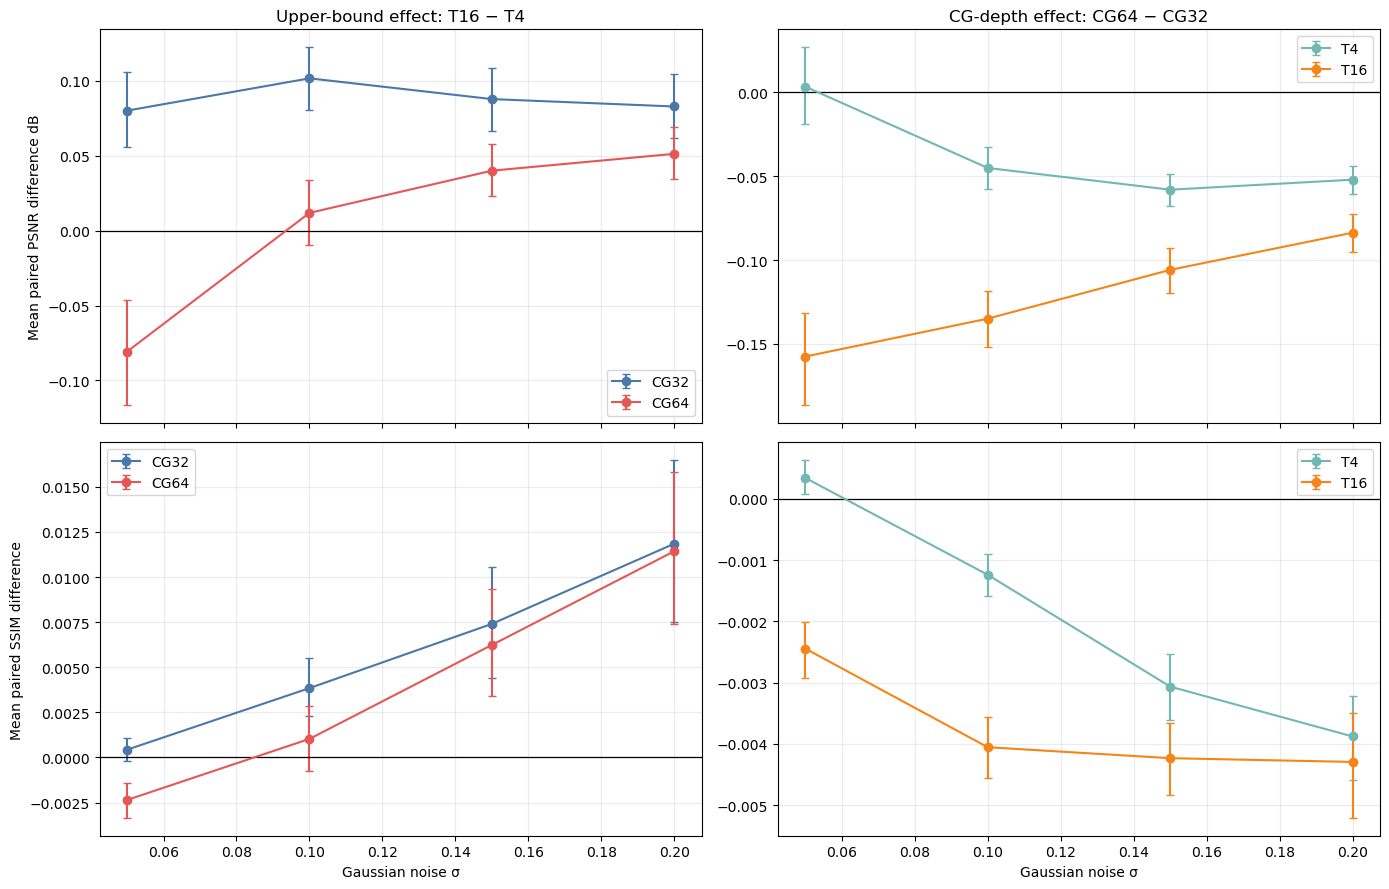

In [22]:
div2k_paired = paired_summary.loc[paired_summary["benchmark_group"] == "div2k"]


def effect_rows(first, second, metric):
    return div2k_paired.loc[
        (div2k_paired["first_method"] == first)
        & (div2k_paired["second_method"] == second)
        & (div2k_paired["metric"] == metric)
    ].sort_values("sigma")


figure, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for row, metric in enumerate(("PSNR", "SSIM")):
    for first, second, label, color in (
        ("U-Tikhonov T16/CG32", "U-Tikhonov T4/CG32", "CG32", "#4c78a8"),
        ("U-Tikhonov T16/CG64", "U-Tikhonov T4/CG64", "CG64", "#e45756"),
    ):
        data = effect_rows(first, second, metric)
        mean = data["mean_difference"].to_numpy()
        error = np.vstack(
            [mean - data["ci95_low"].to_numpy(), data["ci95_high"].to_numpy() - mean]
        )
        axes[row, 0].errorbar(
            data["sigma"], mean, yerr=error, marker="o", capsize=3,
            label=label, color=color,
        )

    for first, second, label, color in (
        ("U-Tikhonov T4/CG64", "U-Tikhonov T4/CG32", "T4", "#72b7b2"),
        ("U-Tikhonov T16/CG64", "U-Tikhonov T16/CG32", "T16", "#f58518"),
    ):
        data = effect_rows(first, second, metric)
        mean = data["mean_difference"].to_numpy()
        error = np.vstack(
            [mean - data["ci95_low"].to_numpy(), data["ci95_high"].to_numpy() - mean]
        )
        axes[row, 1].errorbar(
            data["sigma"], mean, yerr=error, marker="o", capsize=3,
            label=label, color=color,
        )

    axes[row, 0].axhline(0, color="black", linewidth=0.9)
    axes[row, 1].axhline(0, color="black", linewidth=0.9)
    unit = "dB" if metric == "PSNR" else ""
    axes[row, 0].set_ylabel(f"Mean paired {metric} difference {unit}".strip())

axes[0, 0].set_title("Upper-bound effect: T16 − T4")
axes[0, 1].set_title("CG-depth effect: CG64 − CG32")
for axis in axes.ravel():
    axis.grid(alpha=0.25)
    axis.legend()
axes[1, 0].set_xlabel("Gaussian noise σ")
axes[1, 1].set_xlabel("Gaussian noise σ")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "u_tikhonov_2x2_factor_effects.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)


*Figure 5.3*

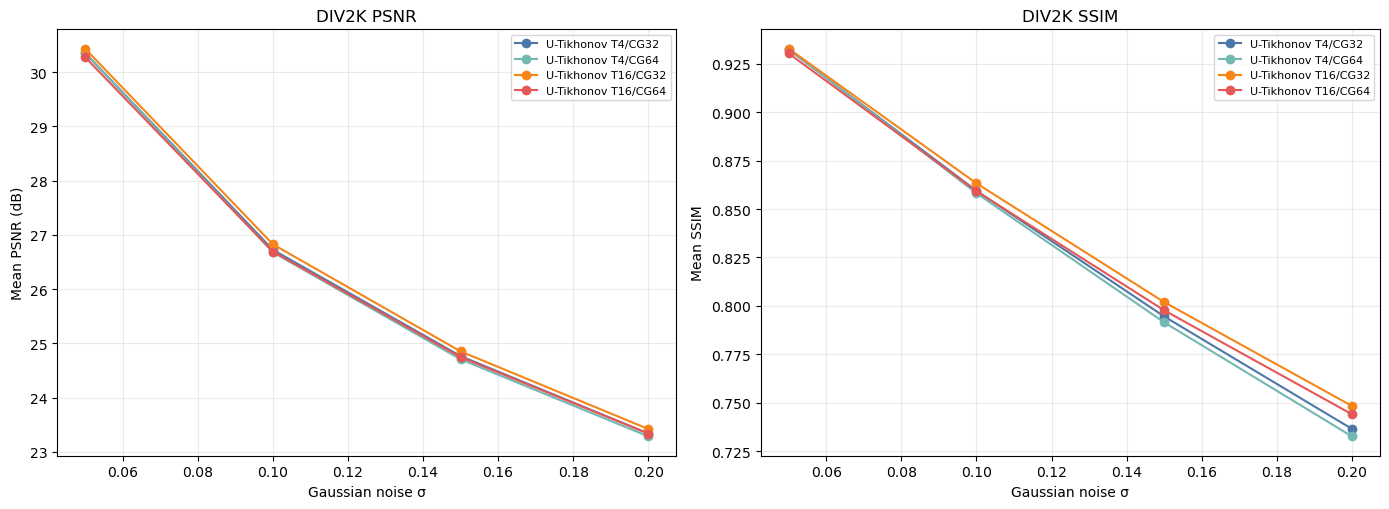

In [10]:
colors = ["#4c78a8", "#72b7b2", "#f58518", "#e45756"]
figure, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for color, method in zip(colors, models):
    rows = div2k_summary.loc[div2k_summary["method"] == method].sort_values("sigma")
    axes[0].plot(rows["sigma"], rows["psnr_mean"], marker="o", color=color, label=method)
    axes[1].plot(rows["sigma"], rows["ssim_mean"], marker="o", color=color, label=method)
axes[0].set(title="DIV2K PSNR", xlabel="Gaussian noise σ", ylabel="Mean PSNR (dB)")
axes[1].set(title="DIV2K SSIM", xlabel="Gaussian noise σ", ylabel="Mean SSIM")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "u_tikhonov_2x2_quality_vs_noise.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)


## Parameter-map diagnostics and inference time


In [11]:
map_columns = [
    column
    for column in div2k_results.columns
    if column.startswith("lambda_")
]
map_diagnostics = (
    div2k_results.groupby(["sigma", "method"], as_index=False)[map_columns]
    .mean(numeric_only=True)
)
map_diagnostics.to_csv(OUTPUT_DIR / "parameter_map_diagnostics.csv", index=False)
display(map_diagnostics)


,sigma,method,lambda_mean,lambda_std,lambda_min,lambda_max,lambda_p01,lambda_median,lambda_p99,lambda_lower_saturation_fraction,lambda_upper_saturation_fraction
0,0.05,U-Tikhonov T16/CG32,3.727778,5.062000,0.004734,32.841297,0.032681,1.897309,21.247335,0.353396,0.017392
1,0.05,U-Tikhonov T16/CG64,3.759665,5.001661,0.001294,32.853381,0.022009,1.968030,20.877424,0.343935,0.012217
2,0.05,U-Tikhonov T4/CG32,2.003290,2.272152,0.000494,8.320140,0.013495,1.220833,7.883549,0.140747,0.060283
3,0.05,U-Tikhonov T4/CG64,2.096163,2.347610,0.000484,8.320324,0.012902,1.299194,8.056439,0.139054,0.074058
4,0.10,U-Tikhonov T16/CG32,6.415587,7.673163,0.008681,33.265803,0.077303,3.657597,29.457931,0.154194,0.036658
5,0.10,U-Tikhonov T16/CG64,6.428391,7.745397,0.001199,33.266268,0.044030,3.604731,29.840365,0.160357,0.032034
6,0.10,U-Tikhonov T4/CG32,3.078436,2.767622,0.000407,8.320334,0.026093,2.328478,8.288338,0.056996,0.118929
7,0.10,U-Tikhonov T4/CG64,3.247677,2.857377,0.000382,8.320335,0.025300,2.545490,8.316976,0.056874,0.148114
8,0.15,U-Tikhonov T16/CG32,8.672742,9.211971,0.009785,33.280963,0.118157,5.457254,31.960607,0.084943,0.058079
9,0.15,U-Tikhonov T16/CG64,8.590353,9.232048,0.001297,33.281061,0.065898,5.332927,32.238879,0.094012,0.054205


In [12]:
sigma_index = SIGMAS.index(0.10)
natural_count = len(div2k_clean)
timing_indices = range(
    sigma_index * natural_count,
    sigma_index * natural_count + natural_count,
)
timing_loader = DataLoader(
    Subset(div2k_benchmark, list(timing_indices)),
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

detail_frames = []
timing_rows = []
for method, model in models.items():
    detail = benchmark_inference_runtime(
        model,
        timing_loader,
        device,
        max_batches=10,
        warmup_runs=3,
        repeats=5,
    )
    detail.insert(0, "method", method)
    detail_frames.append(detail)
    timing_rows.append(runtime_summary(detail, method=method, model=model, device=device))

timing_detail = pd.concat(detail_frames, ignore_index=True)
timing_summary = pd.DataFrame(timing_rows)
timing_detail.to_csv(OUTPUT_DIR / "inference_timing_detail.csv", index=False)
timing_summary.to_csv(OUTPUT_DIR / "inference_time_comparison.csv", index=False)
display(timing_summary.sort_values("mean_runtime_ms_per_image"))


,method,device,device_description,parameter_count,timed_measurements,timed_images_per_repeat,mean_runtime_ms_per_image,std_runtime_ms_per_image,median_runtime_ms_per_image,images_per_second,solver_iterations
2,U-Tikhonov T16/CG32,mps,Apple Metal Performance Shaders (MPS),1925025,50,10,60.089107,3.533679,59.193396,16.641951,32
0,U-Tikhonov T4/CG32,mps,Apple Metal Performance Shaders (MPS),1925025,50,10,61.408670,5.302485,59.706896,16.284346,32
1,U-Tikhonov T4/CG64,mps,Apple Metal Performance Shaders (MPS),1925025,50,10,109.757671,4.675512,109.039417,9.110981,64
3,U-Tikhonov T16/CG64,mps,Apple Metal Performance Shaders (MPS),1925025,50,10,114.610172,9.885761,111.270958,8.725229,64


## Compact Tables for Thesis

In [19]:
THESIS_ASSET_DIR = OUTPUT_DIR / "thesis_assets"
THESIS_ASSET_DIR.mkdir(parents=True, exist_ok=True)


def export_thesis_table(frame, stem, *, caption, label, column_format=None):
    """Save one display-ready table as CSV and a booktabs LaTeX table."""
    csv_path = THESIS_ASSET_DIR / f"{stem}.csv"
    tex_path = THESIS_ASSET_DIR / f"{stem}.tex"
    frame.to_csv(csv_path, index=False)
    alignment = column_format or ("l" * len(frame.columns))
    lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        rf"\begin{{tabular}}{{{alignment}}}",
        r"\toprule",
        " & ".join(map(str, frame.columns)) + r" \\",
        r"\midrule",
    ]
    for row in frame.itertuples(index=False, name=None):
        lines.append(" & ".join(map(str, row)) + r" \\")
    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])
    latex = "\n".join(lines) + "\n"
    tex_path.write_text(latex, encoding="utf-8")
    print("Saved:", csv_path)
    print("Saved:", tex_path)
    return csv_path, tex_path


# Table 3.1 is generated from the checkpoint-verified configuration frame.
configuration_labels = {
    "U-Tikhonov T4/CG32": "T4/32",
    "U-Tikhonov T16/CG32": "T16/32",
    "U-Tikhonov T4/CG64": "T4/64",
    "U-Tikhonov T16/CG64": "T16/64",
}
configuration_order = [
    "U-Tikhonov T4/CG32",
    "U-Tikhonov T16/CG32",
    "U-Tikhonov T4/CG64",
    "U-Tikhonov T16/CG64",
]
table_3_1_rows = []
for method in configuration_order:
    row = model_configuration.loc[model_configuration["method"] == method].iloc[0]
    multiplier = int(row["lambda_multiplier"])
    table_3_1_rows.append({
        "Configuration": configuration_labels[method],
        r"$\lambda_{\max}$": rf"${multiplier}\lambda^*={row['lambda_max']:.5f}$",
        "CG depth": int(row["cg_iterations"]),
    })
table_3_1 = pd.DataFrame(table_3_1_rows)
export_thesis_table(
    table_3_1,
    "table_3_1_u_tikhonov_configurations",
    caption="U-Tikhonov bound--depth configurations.",
    label="tab:u_tikhonov_configurations",
    column_format="lrr",
)
display(table_3_1)

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_3_1_u_tikhonov_configurations.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_3_1_u_tikhonov_configurations.tex


,Configuration,$\lambda_{\max}$,CG depth
0,T4/32,$4\lambda^*=8.32034$,32
1,T16/32,$16\lambda^*=33.28134$,32
2,T4/64,$4\lambda^*=8.32034$,64
3,T16/64,$16\lambda^*=33.28134$,64


In [20]:
method_columns = OrderedDict([
    ("T4/32", "U-Tikhonov T4/CG32"),
    ("T4/64", "U-Tikhonov T4/CG64"),
    ("T16/32", "U-Tikhonov T16/CG32"),
    ("T16/64", "U-Tikhonov T16/CG64"),
])
table_5_3_rows = []
for sigma in SIGMAS:
    rows = div2k_summary.loc[np.isclose(div2k_summary["sigma"], sigma)].set_index("method")
    record = {r"$\sigma$": f"{sigma:.2f}"}
    for display_name, method in method_columns.items():
        row = rows.loc[method]
        record[display_name] = f"{row['psnr_mean']:.3f}/{row['ssim_mean']:.4f}"
    table_5_3_rows.append(record)
table_5_3 = pd.DataFrame(table_5_3_rows)
export_thesis_table(
    table_5_3,
    "table_5_3_u_tikhonov_2x2_div2k",
    caption="U-Tikhonov factorial experiment on DIV2K. Entries are mean PSNR/SSIM over 100 images.",
    label="tab:u_tikhonov_2x2_div2k",
    column_format="lrrrr",
)
display(table_5_3)


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_3_u_tikhonov_2x2_div2k.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_3_u_tikhonov_2x2_div2k.tex


,$\sigma$,T4/32,T4/64,T16/32,T16/64
0,0.05,30.349/0.9324,30.353/0.9328,30.430/0.9328,30.272/0.9304
1,0.10,26.724/0.8595,26.679/0.8582,26.826/0.8633,26.691/0.8592
2,0.15,24.766/0.7945,24.707/0.7915,24.853/0.8019,24.748/0.7977
3,0.20,23.340/0.7365,23.288/0.7326,23.423/0.7483,23.339/0.7440


In [21]:
# Table 5.4: aggregate pixel diagnostics at the lowest and highest noise.
table_5_4_rows = []
diagnostic_order = [
    "U-Tikhonov T4/CG32",
    "U-Tikhonov T4/CG64",
    "U-Tikhonov T16/CG32",
    "U-Tikhonov T16/CG64",
]
for method in diagnostic_order:
    for sigma in (0.05, 0.20):
        row = map_diagnostics.loc[
            (map_diagnostics["method"] == method)
            & np.isclose(map_diagnostics["sigma"], sigma)
        ]
        if len(row) != 1:
            raise RuntimeError(f"Expected one map-diagnostic row for {method}, sigma={sigma}.")
        row = row.iloc[0]
        table_5_4_rows.append({
            "Configuration": configuration_labels[method],
            r"$\sigma$": f"{sigma:.2f}",
            r"Mean $\lambda$": f"{row['lambda_mean']:.3f}",
            "99th percentile": f"{row['lambda_p99']:.3f}",
            "Near upper bound (\\%)": f"{100.0 * row['lambda_upper_saturation_fraction']:.2f}",
        })
table_5_4 = pd.DataFrame(table_5_4_rows)
export_thesis_table(
    table_5_4,
    "table_5_4_u_tikhonov_map_diagnostics",
    caption="DIV2K U-Tikhonov map diagnostics at the lowest and highest tested noise levels. The final column is the percentage of pixels within 1\\% of the configured upper bound.",
    label="tab:u_tikhonov_map_diagnostics",
    column_format="llrrr",
)
display(table_5_4)


# Table 5.5: paired geometric observations at sigma=0.05. Boldface is
# applied separately to the best PSNR and best SSIM within each phantom.
phantom_order = OrderedDict([
    ("Disk", "disk.png"),
    ("Nested rectangles", "nested_rectangles.png"),
    ("Square gradient", "square_gradient.png"),
    ("Step edge", "step_edge.png"),
    ("Triangle", "triangle.png"),
])
geometry_005 = long_results.loc[
    (long_results["dataset"] == "geometry")
    & np.isclose(long_results["sigma"], 0.05)
].copy()


def bold_if_best(text, value, best):
    return rf"\textbf{{{text}}}" if np.isclose(value, best) else text


table_5_5_rows = []
for phantom_label, image_name in phantom_order.items():
    rows = geometry_005.loc[geometry_005["image_name"] == image_name].set_index("method")
    best_psnr = rows["recon_psnr"].max()
    best_ssim = rows["recon_ssim"].max()
    record = {"Phantom": phantom_label}
    for display_name, method in method_columns.items():
        row = rows.loc[method]
        psnr = bold_if_best(f"{row['recon_psnr']:.3f}", row["recon_psnr"], best_psnr)
        ssim = bold_if_best(f"{row['recon_ssim']:.4f}", row["recon_ssim"], best_ssim)
        record[display_name] = f"{psnr}/{ssim}"
    table_5_5_rows.append(record)

mean_rows = geometry_005.groupby("method", as_index=True)[["recon_psnr", "recon_ssim"]].mean()
best_mean_psnr = mean_rows["recon_psnr"].max()
best_mean_ssim = mean_rows["recon_ssim"].max()
mean_record = {"Phantom": "Mean"}
for display_name, method in method_columns.items():
    row = mean_rows.loc[method]
    psnr = bold_if_best(f"{row['recon_psnr']:.3f}", row["recon_psnr"], best_mean_psnr)
    ssim = bold_if_best(f"{row['recon_ssim']:.4f}", row["recon_ssim"], best_mean_ssim)
    mean_record[display_name] = f"{psnr}/{ssim}"
table_5_5_rows.append(mean_record)

table_5_5 = pd.DataFrame(table_5_5_rows)
export_thesis_table(
    table_5_5,
    "table_5_5_geometric_phantoms",
    caption="Geometric-phantom results at $\\sigma=0.05$. Entries are PSNR/SSIM; bold type marks the best value for each metric and phantom.",
    label="tab:geometric_phantoms",
    column_format="lrrrr",
)
display(table_5_5)


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_4_u_tikhonov_map_diagnostics.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_4_u_tikhonov_map_diagnostics.tex


,Configuration,$\sigma$,Mean $\lambda$,99th percentile,Near upper bound (\%)
0,T4/32,0.05,2.003,7.884,6.03
1,T4/32,0.20,4.483,8.320,22.29
2,T4/64,0.05,2.096,8.056,7.41
3,T4/64,0.20,4.771,8.320,28.11
4,T16/32,0.05,3.728,21.247,1.74
5,T16/32,0.20,10.398,32.778,7.58
6,T16/64,0.05,3.760,20.877,1.22
7,T16/64,0.20,10.333,32.913,7.16


Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_5_geometric_phantoms.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_5_5_geometric_phantoms.tex


,Phantom,T4/32,T4/64,T16/32,T16/64
0,Disk,38.469/0.9800,38.123/0.9791,\textbf{39.409}/\textbf{0.9929},39.256/0.9917
1,Nested rectangles,37.803/0.9778,37.129/0.9763,38.512/\textbf{0.9894},\textbf{38.586}/0.9887
2,Square gradient,\textbf{42.292}/0.9838,41.282/0.9830,42.158/\textbf{0.9874},41.905/0.9870
3,Step edge,44.485/0.9822,42.809/0.9813,\textbf{45.567}/\textbf{0.9951},44.599/0.9945
4,Triangle,38.101/0.9796,37.907/0.9781,38.736/\textbf{0.9912},\textbf{39.285}/0.9899
5,Mean,40.230/0.9807,39.450/0.9796,\textbf{40.877}/\textbf{0.9912},40.726/0.9904


In [26]:
# Combines:
#   1. the complete 300-epoch training histories for each configuration, and
#   2. the inference timings already measured earlier in this notebook.
#
# No model training or inference is rerun here.

cost_labels = {
    "U-Tikhonov T4/CG32": "T4/CG32",
    "U-Tikhonov T16/CG32": "T16/CG32",
    "U-Tikhonov T4/CG64": "T4/CG64",
    "U-Tikhonov T16/CG64": "T16/CG64",
}

cost_rows = []

for method in configuration_order:
    # ------------------------------------------------------------
    # 1. Recorded total training time from the complete history
    # ------------------------------------------------------------
    history_path = checkpoint_paths[method].parent / "history.csv"

    if not history_path.is_file():
        raise FileNotFoundError(
            f"Missing training history for {method}: {history_path}"
        )

    history = pd.read_csv(history_path)

    required_history_columns = {"epoch", "epoch_time_sec"}
    missing = required_history_columns - set(history.columns)
    if missing:
        raise RuntimeError(
            f"{method}: history is missing columns {sorted(missing)}. "
            f"Available columns: {list(history.columns)}"
        )

    epochs = history["epoch"].astype(int).to_numpy()

    # The convergence-matched comparison is supposed to use complete
    # histories through epoch 300. Check this explicitly before summing.
    if (
        len(history) != 300
        or epochs.min() != 1
        or epochs.max() != 300
        or len(np.unique(epochs)) != 300
    ):
        raise RuntimeError(
            f"{method}: expected one complete 300-epoch history "
            f"(epochs 1--300), but found {len(history)} rows with "
            f"epoch range {epochs.min()}--{epochs.max()}."
        )

    epoch_times = pd.to_numeric(
        history["epoch_time_sec"],
        errors="raise",
    )

    if not np.isfinite(epoch_times).all():
        raise RuntimeError(
            f"{method}: non-finite epoch_time_sec values found."
        )

    training_hours = float(epoch_times.sum() / 3600.0)

    # ------------------------------------------------------------
    # 2. Inference timing already measured earlier in Notebook 08
    # ------------------------------------------------------------
    timing_row = timing_summary.loc[
        timing_summary["method"] == method
    ]

    if len(timing_row) != 1:
        raise RuntimeError(
            f"{method}: expected exactly one timing-summary row, "
            f"found {len(timing_row)}."
        )

    timing_row = timing_row.iloc[0]

    cost_rows.append(
        {
            "Configuration": cost_labels[method],
            "CG depth": int(timing_row["solver_iterations"]),
            "Training time (h)": f"{training_hours:.2f}",
            "Mean inference (ms/image)": (
                f"{float(timing_row['mean_runtime_ms_per_image']):.2f}"
            ),
        }
    )

ablation_cost_table = pd.DataFrame(cost_rows)

# Save thesis-ready CSV and LaTeX versions using the helper already
# defined in the Compact Tables for Thesis section.
export_thesis_table(
    ablation_cost_table,
    "table_u_tikhonov_ablation_cost",
    caption=(
        "Recorded computational cost of the convergence-matched "
        "U-Tikhonov $2\\times2$ ablation. Training time is the sum of "
        "the recorded per-epoch durations over the complete 300-epoch "
        "history. Inference time is the mean over ten DIV2K images at "
        "$\\sigma=0.10$, with three warm-up passes and five timed repeats."
    ),
    label="tab:u_tikhonov_ablation_cost",
    column_format="lrrr",
)

display(ablation_cost_table)

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_u_tikhonov_ablation_cost.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/u_tikhonov_convergence_matched_2x2/thesis_assets/table_u_tikhonov_ablation_cost.tex


,Configuration,CG depth,Training time (h),Mean inference (ms/image)
0,T4/CG32,32,7.53,61.41
1,T16/CG32,32,6.90,60.09
2,T4/CG64,64,11.29,109.76
3,T16/CG64,64,11.37,114.61
